In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist

### Load embeddings and scores

In [2]:
root_dir = "../../saved_models/STCRL_transfer_learning/embeddings/"
monkeypr_data_path = root_dir + "embedded_trajectories_monkey.csv"
ucpmp_data_path = root_dir + "embedded_trajectories_UCPMP.csv"
# Load the data
monkeypr_df = pd.read_csv(monkeypr_data_path)
ucpmp_df = pd.read_csv(ucpmp_data_path)

In [3]:
monkeypr_df['task_label'] = "Reaching"
monkeypr_df.columns = ['exp_type', 'session_no', 'trial_no', 'Time', 'HandPos', 'TargetPos',
       'time_diff_ms', 'path', 'target_poisiton', 'normalized_trajectory',
       'Cohort', 'completion_time', 'rmsd', 'is_success',
       'trajectory_embedding_default', 'exploration_score',
       'exploitation_score', 'exploration_exploitation_ratio', 'task_label']
print(monkeypr_df.columns)
print(monkeypr_df.shape)
monkeypr_df


Index(['exp_type', 'session_no', 'trial_no', 'Time', 'HandPos', 'TargetPos',
       'time_diff_ms', 'path', 'target_poisiton', 'normalized_trajectory',
       'Cohort', 'completion_time', 'rmsd', 'is_success',
       'trajectory_embedding_default', 'exploration_score',
       'exploitation_score', 'exploration_exploitation_ratio', 'task_label'],
      dtype='object')
(23639, 19)


,exp_type,session_no,trial_no,Time,HandPos,TargetPos,time_diff_ms,path,target_poisiton,normalized_trajectory,Cohort,completion_time,rmsd,is_success,trajectory_embedding_default,exploration_score,exploitation_score,exploration_exploitation_ratio,task_label
0,Scott_2001_e1,1,1,[0.006;0.016;0.026;0.036;0.046;0.056;0.066;0.0...,[-13.166 280.695;-13.3428 280.618;-13.5578 280...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 6. 16. 26. 36. 46. 56. 66. 7...,"[(-13.166, 280.695), (-13.3428, 280.618), (-13...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 6.00000000e...,Monkey,4400.0,28.846063,0,[ 2.746458 1.3643794 -0.11187054 -1.244191...,0.087047,0.000000,8.704692,Reaching
1,Scott_2001_e1,1,2,[0.052;0.062;0.072;0.082;0.092;0.102;0.112;0.1...,[-18.7382 283.289;-19.4048 282.418;-19.9414 28...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 52. 62. 72. 82. 92. 102. 112. 12...,"[(-18.7382, 283.289), (-19.4048, 282.418), (-1...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 5.20000000e...,Monkey,4630.0,32.107887,0,[ 2.6919947 1.3441939 -0.08182078 -1.208788...,0.052366,0.641779,0.080343,Reaching
2,Scott_2001_e1,1,3,[1.064;1.074;1.084;1.094;1.104;1.114;1.124;1.1...,[-20.5466 283.837;-20.168 283.326;-19.64 282.8...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[1064. 1074. 1084. 1094. 1104. 1114. 1124. 113...,"[(-20.5466, 283.837), (-20.168, 283.326), (-19...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 1.06400000e...,Monkey,4550.0,26.912938,0,[ 1.6539602 0.9195859 0.44686127 -0.457816...,0.247908,0.269935,0.885591,Reaching
3,Scott_2001_e1,1,4,[0.352;0.362;0.372;0.382;0.392;0.402;0.412;0.4...,[-14.548 281.899;-14.9 281.372;-15.251 280.844...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 352. 362. 372. 382. 392. 402. 412. 42...,"[(-14.548, 281.899), (-14.9, 281.372), (-15.25...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 3.52000000e...,Monkey,3990.0,28.657583,0,[ 2.2790565 1.1866221 0.13658434 -0.936977...,0.057048,0.619894,0.090568,Reaching
4,Scott_2001_e1,1,5,[0.046;0.056;0.066;0.076;0.086;0.096;0.106;0.1...,[-20.558 279.653;-20.508 279.572;-20.293 279.5...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 46. 56. 66. 76. 86. 96. 106. 11...,"[(-20.558, 279.653), (-20.508, 279.572), (-20....","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 4.60000000e...,Monkey,3840.0,29.393611,0,[ 2.6876135 1.3426018 -0.07927531 -1.206956...,0.070156,0.568284,0.121318,Reaching
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23634,Scott_2001_e5,88,16,[0.681;0.691;0.701;0.711;0.721;0.731;0.741;0.7...,[-5.489 295.829;-5.39344 295.876;-5.1416 295.8...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...,[ 681. 691. 701. 711. 721. 731. 741. 75...,"[(-5.489, 295.829), (-5.39344, 295.876), (-5.1...","(-7.0, 229.0)",[[ 0.00000000e+00 0.00000000e+00 6.81000000e...,Monkey,4250.0,6.226852,0,[ 1.9410549 1.0486915 0.30612326 -0.687752...,0.003766,0.582239,0.006358,Reaching
23635,Scott_2001_e5,88,17,[0.47;0.48;0.49;0.5;0.51;0.52;0.53;0.54;0.55;0...,[-0.2296 289.508;-0.537 289.575;-0.81 289.659;...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...,[ 470. 480. 490. 500. 510. 520. 530. 54...,"[(-0.2296, 289.508), (-0.537, 289.575), (-0.81...","(-7.0, 229.0)",[[ 0.00000000e+00 0.00000000e+00 4.70000000e...,Monkey,4450.0,2.236935,1,[ 2.19201064e+00 1.15295780e+00 1.80654690e-...,0.012251,0.642648,0.018771,Reaching
23636,Scott_2001_e5,88,18,[0.3;0.31;0.32;0.33;0.34;0.35;0.36;0.37;0.38;0...,[-6.225 295.896;-6.225 295.896;-6.0372 295.957...,[-7 229;-7 229;-7 229;-7 229;-7 229;-7 229;-7 ...,[ 300. 310. 320. 330. 340. 350. 360. 37...,"[(-6.225, 295.896), (-6.225, 295.896), (-6.037...","(-7.0, 229.0)",[[ 0.00000000e+00 0.00000000e+00 3.00000000e...,Monkey,4590.0,2.634324,0,[ 2.3986273 1.2328436 0.07562588 -1.017312...,0.006971,0.709553,0.009688,Reaching
23637,Scott_2001_e5,88,19,[0.16;0.17;0.18;0.19;0.2;0.21;0.22;0.23;0.24;0...,[-9.774 288.568;-9.774 288.568;-9.774 288.568;...,[-7 229;-7 229;-7 229;-7 229;-7 229;

In [4]:
# Trials per session (within each experiment)
trials_per_session = (
    monkeypr_df.groupby(['exp_type', 'session_no'])['trial_no']
    .nunique()
    .reset_index(name='trials_per_session')
    .sort_values(['exp_type', 'session_no'])
)

# Summary per experiment: number of sessions + trial/session stats
exp_summary = (
    trials_per_session.groupby('exp_type')
    .agg(
        n_sessions=('session_no', 'nunique'),
        avg_trials_per_session=('trials_per_session', 'mean'),
        min_trials_per_session=('trials_per_session', 'min'),
        max_trials_per_session=('trials_per_session', 'max')
    )
    .reset_index()
    .sort_values('exp_type')
)

display(exp_summary)
display(trials_per_session)

,exp_type,n_sessions,avg_trials_per_session,min_trials_per_session,max_trials_per_session
0,Scott_2001_e1,185,45.783784,12,49
1,Scott_2001_e2,259,42.482625,16,50
2,Scott_2001_e3,29,46.827586,32,48
3,Scott_2001_e4,26,44.615385,16,48
4,Scott_2001_e5,88,18.727273,4,20


,exp_type,session_no,trials_per_session
0,Scott_2001_e1,1,48
1,Scott_2001_e1,2,48
2,Scott_2001_e1,3,48
3,Scott_2001_e1,4,48
4,Scott_2001_e1,5,48
...,...,...,...
582,Scott_2001_e5,84,12
583,Scott_2001_e5,85,20
584,Scott_2001_e5,86,20
585,Scott_2001_e5,87,20


In [5]:
# Keep only (exp_type, session_no) groups that have exactly 48 unique trials
valid_sessions = trials_per_session.loc[
    trials_per_session["trials_per_session"] == 48, ["exp_type", "session_no"]
]

monkeypr_df_filtered = monkeypr_df.merge(valid_sessions, on=["exp_type", "session_no"], how="inner")

print(monkeypr_df_filtered.shape)
monkeypr_df_filtered.head()

(18432, 19)


,exp_type,session_no,trial_no,Time,HandPos,TargetPos,time_diff_ms,path,target_poisiton,normalized_trajectory,Cohort,completion_time,rmsd,is_success,trajectory_embedding_default,exploration_score,exploitation_score,exploration_exploitation_ratio,task_label
0,Scott_2001_e1,1,1,[0.006;0.016;0.026;0.036;0.046;0.056;0.066;0.0...,[-13.166 280.695;-13.3428 280.618;-13.5578 280...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 6. 16. 26. 36. 46. 56. 66. 7...,"[(-13.166, 280.695), (-13.3428, 280.618), (-13...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 6.00000000e...,Monkey,4400.0,28.846063,0,[ 2.746458 1.3643794 -0.11187054 -1.244191...,0.087047,0.000000,8.704692,Reaching
1,Scott_2001_e1,1,2,[0.052;0.062;0.072;0.082;0.092;0.102;0.112;0.1...,[-18.7382 283.289;-19.4048 282.418;-19.9414 28...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 52. 62. 72. 82. 92. 102. 112. 12...,"[(-18.7382, 283.289), (-19.4048, 282.418), (-1...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 5.20000000e...,Monkey,4630.0,32.107887,0,[ 2.6919947 1.3441939 -0.08182078 -1.208788...,0.052366,0.641779,0.080343,Reaching
2,Scott_2001_e1,1,3,[1.064;1.074;1.084;1.094;1.104;1.114;1.124;1.1...,[-20.5466 283.837;-20.168 283.326;-19.64 282.8...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[1064. 1074. 1084. 1094. 1104. 1114. 1124. 113...,"[(-20.5466, 283.837), (-20.168, 283.326), (-19...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 1.06400000e...,Monkey,4550.0,26.912938,0,[ 1.6539602 0.9195859 0.44686127 -0.457816...,0.247908,0.269935,0.885591,Reaching
3,Scott_2001_e1,1,4,[0.352;0.362;0.372;0.382;0.392;0.402;0.412;0.4...,[-14.548 281.899;-14.9 281.372;-15.251 280.844...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 352. 362. 372. 382. 392. 402. 412. 42...,"[(-14.548, 281.899), (-14.9, 281.372), (-15.25...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 3.52000000e...,Monkey,3990.0,28.657583,0,[ 2.2790565 1.1866221 0.13658434 -0.936977...,0.057048,0.619894,0.090568,Reaching
4,Scott_2001_e1,1,5,[0.046;0.056;0.066;0.076;0.086;0.096;0.106;0.1...,[-20.558 279.653;-20.508 279.572;-20.293 279.5...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 46. 56. 66. 76. 86. 96. 106. 11...,"[(-20.558, 279.653), (-20.508, 279.572), (-20....","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 4.60000000e...,Monkey,3840.0,29.393611,0,[ 2.6876135 1.3426018 -0.07927531 -1.206956...,0.070156,0.568284,0.121318,Reaching


In [6]:
# Trials per session (within each experiment)
trials_per_session = (
    monkeypr_df_filtered.groupby(['exp_type', 'session_no'])['trial_no']
    .nunique()
    .reset_index(name='trials_per_session')
    .sort_values(['exp_type', 'session_no'])
)

# Summary per experiment: number of sessions + trial/session stats
exp_summary = (
    trials_per_session.groupby('exp_type')
    .agg(
        n_sessions=('session_no', 'nunique'),
        avg_trials_per_session=('trials_per_session', 'mean'),
        min_trials_per_session=('trials_per_session', 'min'),
        max_trials_per_session=('trials_per_session', 'max')
    )
    .reset_index()
    .sort_values('exp_type')
)

display(exp_summary)
display(trials_per_session)

,exp_type,n_sessions,avg_trials_per_session,min_trials_per_session,max_trials_per_session
0,Scott_2001_e1,153,48.0,48,48
1,Scott_2001_e2,185,48.0,48,48
2,Scott_2001_e3,25,48.0,48,48
3,Scott_2001_e4,21,48.0,48,48


,exp_type,session_no,trials_per_session
0,Scott_2001_e1,1,48
1,Scott_2001_e1,2,48
2,Scott_2001_e1,3,48
3,Scott_2001_e1,4,48
4,Scott_2001_e1,5,48
...,...,...,...
379,Scott_2001_e4,21,48
380,Scott_2001_e4,22,48
381,Scott_2001_e4,24,48
382,Scott_2001_e4,25,48


In [7]:
ucpmp_df['task_label'] = "Reaching"

In [8]:

print(ucpmp_df.columns)
print(ucpmp_df.shape)
ucpmp_df.head()

Index(['participant_id', 'Age', 'day', 'trial_hand', 'session_no', 'planet',
       'start_time', 'end_time', 'target_pos', 'planet_pos', 'path',
       'time_string', 'time_diff_ms', 'completion_time', 'movement_dist',
       'trial_start_time', 'trial_no', 'target_point_x', 'target_point_y',
       'start_point_x', 'start_point_y', 'Cohort', 'actual_dist', 'rmsd',
       'block_no', 'distances', 'normalized_trajectory',
       'original_target_angle', 'rotation_angle', 'original_end_vector',
       'is_success', 'trajectory_embedding_default', 'task_type',
       'exploration_score', 'exploitation_score', 'novelty',
       'avg_similarity_to_window', 'max_similarity_to_window', 'trial_seq',
       'task_label', 'exploration_exploitation_ratio', 'learning_rate',
       'strategy_stability'],
      dtype='object')
(4800, 43)


,participant_id,Age,day,trial_hand,session_no,planet,start_time,end_time,target_pos,planet_pos,...,exploration_score,exploitation_score,novelty,avg_similarity_to_window,max_similarity_to_window,trial_seq,task_label,exploration_exploitation_ratio,learning_rate,strategy_stability
0,MHEALTH101,9,Day-1,Left,1,mercury,2025-02-28 13:23:43.2150,2025-02-28 13:24:00.4870,"[(48.2953931550412, -48.29539315504119)]","[(-597.625, 256.0)]",...,0.046664,0.000000,1.000000,0.000000,0.000000,1.0,Reaching,4.666375,NaN,NaN
1,MHEALTH101,9,Day-1,Left,1,venus,2025-02-28 13:24:00.4870,2025-02-28 13:24:04.9060,"[(6.856014457521658e-15, -111.9672131147541)]","[(-597.625, 341.3333435058594)]",...,0.016760,0.741022,0.379219,0.469689,0.725048,7.0,Reaching,0.022317,-3.480008,0.551814
2,MHEALTH101,9,Day-1,Left,1,earth,2025-02-28 13:24:04.9060,2025-02-28 13:24:07.6490,"[(9.840397221384027e-15, 160.7058823529412)]","[(-597.625, -341.3333435058594)]",...,0.008933,0.840699,0.215693,0.611945,0.822576,13.0,Reaching,0.010501,3.054611,0.980137
3,MHEALTH101,9,Day-1,Left,1,mars,2025-02-28 13:24:07.6500,2025-02-28 13:24:09.9340,"[(155.79159082271354, 155.79159082271352)]","[(-597.625, -256.0)]",...,0.006845,0.866130,0.173103,0.564204,0.847459,19.0,Reaching,0.007812,-4.096087,0.981390
4,MHEALTH101,9,Day-1,Left,1,jupiter,2025-02-28 13:24:09.9340,2025-02-28 13:24:17.5220,"[(-262.6923076923077, 3.217052937760162e-14)]","[(597.625, 256.0)]",...,0.004122,0.916806,0.114774,0.561665,0.897043,25.0,Reaching,0.004448,-30.796087,0.992157


In [9]:
# Trials per session (within each participant)
ucpmp_trials_per_session = (
    ucpmp_df.groupby(['participant_id', 'session_no'])['trial_seq']
    .nunique()
    .reset_index(name='trials_per_session')
    .sort_values(['participant_id', 'session_no'])
)

# Summary per participant: number of sessions + trial/session stats
ucpmp_participant_summary = (
    ucpmp_trials_per_session.groupby('participant_id')
    .agg(
        n_sessions=('session_no', 'nunique'),
        avg_trials_per_session=('trials_per_session', 'mean'),
        min_trials_per_session=('trials_per_session', 'min'),
        max_trials_per_session=('trials_per_session', 'max')
    )
    .reset_index()
    .sort_values('participant_id')
)

display(ucpmp_participant_summary)
display(ucpmp_trials_per_session)

,participant_id,n_sessions,avg_trials_per_session,min_trials_per_session,max_trials_per_session
0,MHEALTH101,2,48.0,48,48
1,MHEALTH102,2,48.0,48,48
2,MHEALTH103,2,48.0,48,48
3,MHEALTH104,2,48.0,48,48
4,MHEALTH105,2,48.0,48,48
5,MHEALTH106,2,48.0,48,48
6,MHEALTH107,2,48.0,48,48
7,MHEALTH108,2,48.0,48,48
8,MHEALTH109,2,48.0,48,48
9,MHEALTH110,2,48.0,48,48


,participant_id,session_no,trials_per_session
0,MHEALTH101,1,48
1,MHEALTH101,2,48
2,MHEALTH102,1,48
3,MHEALTH102,2,48
4,MHEALTH103,1,48
...,...,...,...
95,MHEALTH212,2,48
96,MHEALTH213,1,48
97,MHEALTH213,2,48
98,MHEALTH214,1,48


### Highly trained (monkey),simple task VS Untrained, Simple task E-E ratio

In [10]:
save_path = "../plots/comparison/monkeyPR_vs_UCPMP/"

,group,mean,ci_low,ci_high,n_units
0,Monkey,0.055629,0.042469,0.068788,384
1,UCP,0.283508,0.144173,0.422843,10
2,TD,0.123079,0.099601,0.146557,40


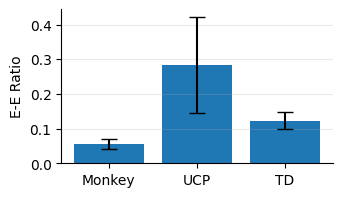

In [11]:
# Mean ± 95% CI of E–E ratio: Monkey vs UCP vs TD
ratio_col = "exploration_exploitation_ratio"

if ratio_col not in monkeypr_df_filtered.columns:
    raise KeyError(f"{ratio_col} not found in monkeypr_df_filtered. Available: {list(monkeypr_df_filtered.columns)}")
if ratio_col not in ucpmp_df.columns:
    raise KeyError(f"{ratio_col} not found in ucpmp_df. Available: {list(ucpmp_df.columns)}")

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

ucpmp_cohort_col = _find_col(ucpmp_df, ["Cohort", "cohort", "GROUP", "Group", "group"])
if ucpmp_cohort_col is None:
    raise KeyError(
        "Could not find a cohort column in ucpmp_df. Expected one of: Cohort/cohort/Group/group"
    )

# --- Monkey: treat each (exp_type, session_no) as the independent unit (48 trials/session)
monkey_session_means = (
    monkeypr_df_filtered
    .assign(**{ratio_col: pd.to_numeric(monkeypr_df_filtered[ratio_col], errors="coerce")})
    .dropna(subset=[ratio_col])
    .groupby(["exp_type", "session_no"], as_index=False)[ratio_col]
    .mean()
    .rename(columns={ratio_col: "unit_mean"})
["unit_mean"]
 )

# --- Humans (UCP/TD): treat each participant as the independent unit (96 trials/participant)
ucpmp_df2 = ucpmp_df.copy()
ucpmp_df2[ucpmp_cohort_col] = ucpmp_df2[ucpmp_cohort_col].astype(str).str.strip()
ucpmp_df2[ratio_col] = pd.to_numeric(ucpmp_df2[ratio_col], errors="coerce")

ucpmp_df2["cohort_norm"] = (
    ucpmp_df2[ucpmp_cohort_col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        "UCPMP": "UCP",
        "UCP ": "UCP",
        "UCP": "UCP",
        "TD": "TD",
        "TDC": "TD",
        "TYPICAL": "TD",
        "CONTROL": "TD",
    })
)

ucpmp_df2 = ucpmp_df2.dropna(subset=[ratio_col])
ucpmp_df2 = ucpmp_df2[ucpmp_df2["cohort_norm"].isin(["UCP", "TD"])]

human_participant_means = (
    ucpmp_df2
    .groupby(["cohort_norm", "participant_id"], as_index=False)[ratio_col]
    .mean()
    .rename(columns={ratio_col: "unit_mean"})
)

def mean_ci_t(x, alpha=0.05):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    n = int(x.shape[0])
    mean = float(x.mean()) if n else np.nan
    if n < 2:
        return mean, np.nan, np.nan, n
    sem = stats.sem(x, nan_policy="omit")
    h = stats.t.ppf(1 - alpha / 2, df=n - 1) * sem
    return mean, mean - h, mean + h, n

rows = []
m, lo, hi, n = mean_ci_t(monkey_session_means)
rows.append({"group": "Monkey", "mean": m, "ci_low": lo, "ci_high": hi, "n_units": n})

for cohort in ["UCP", "TD"]:
    vals = human_participant_means.loc[human_participant_means["cohort_norm"] == cohort, "unit_mean"]
    m, lo, hi, n = mean_ci_t(vals)
    rows.append({"group": cohort, "mean": m, "ci_low": lo, "ci_high": hi, "n_units": n})

summary_df = pd.DataFrame(rows)
display(summary_df)

# Plot: Mean ± 95% CI
order = ["Monkey", "UCP", "TD"]
plot_df = summary_df.set_index("group").loc[order].reset_index()

yerr = np.vstack([
    plot_df["mean"] - plot_df["ci_low"],
    plot_df["ci_high"] - plot_df["mean"],
])

fig, ax = plt.subplots(figsize=(3.5, 2.0))
ax.bar(plot_df["group"], plot_df["mean"], yerr=yerr, capsize=6)
ax.set_ylabel("E-E Ratio")
# ax.set_title("E–E ratio: Mean ± 95% CI")
ax.grid(axis="y", alpha=0.25)
sns.despine()
plt.show()

Max x_index by group: {'Monkey': 48, 'TD': 48, 'UCP': 48}


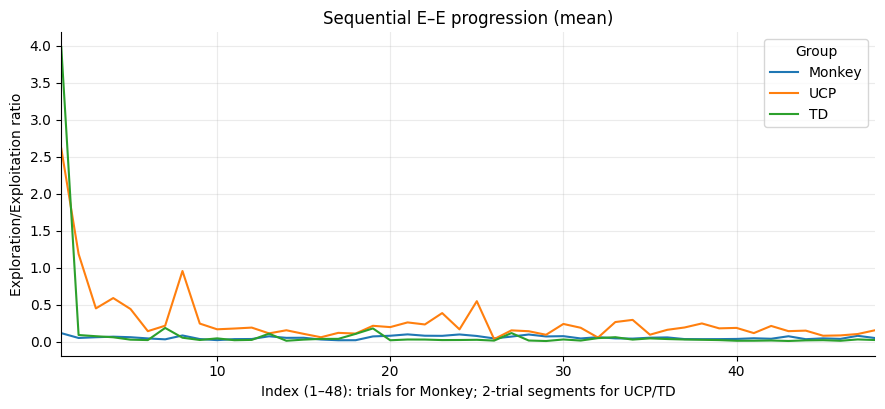

In [12]:
# Sequential E–E progression over trials (mean line only)
ratio_col = "exploration_exploitation_ratio"

# Make this cell runnable standalone
if "mean_ci_t" not in globals():
    def mean_ci_t(x, alpha=0.05):
        x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
        n = int(x.shape[0])
        mean = float(x.mean()) if n else np.nan
        if n < 2:
            return mean, np.nan, np.nan, n
        sem = stats.sem(x, nan_policy="omit")
        h = stats.t.ppf(1 - alpha / 2, df=n - 1) * sem
        return mean, mean - h, mean + h, n

if "ucpmp_df2" not in globals():
    def _find_col(df, candidates):
        for c in candidates:
            if c in df.columns:
                return c
        return None

    ucpmp_cohort_col = _find_col(ucpmp_df, ["Cohort", "cohort", "GROUP", "Group", "group"])
    if ucpmp_cohort_col is None:
        raise KeyError(
            "Could not find a cohort column in ucpmp_df. Expected one of: Cohort/cohort/Group/group"
        )

    ucpmp_df2 = ucpmp_df.copy()
    ucpmp_df2[ucpmp_cohort_col] = ucpmp_df2[ucpmp_cohort_col].astype(str).str.strip()
    ucpmp_df2[ratio_col] = pd.to_numeric(ucpmp_df2[ratio_col], errors="coerce")
    ucpmp_df2["cohort_norm"] = (
        ucpmp_df2[ucpmp_cohort_col]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({
            "UCPMP": "UCP",
            "UCP ": "UCP",
            "UCP": "UCP",
            "TD": "TD",
            "TDC": "TD",
            "TYPICAL": "TD",
            "CONTROL": "TD",
        })
    )
    ucpmp_df2 = ucpmp_df2.dropna(subset=[ratio_col])
    ucpmp_df2 = ucpmp_df2[ucpmp_df2["cohort_norm"].isin(["UCP", "TD"])]

# --- Monkey progression: x = trial_no within session (1..48)
monkey_seq = monkeypr_df_filtered[["exp_type", "session_no", "trial_no", ratio_col]].copy()
monkey_seq[ratio_col] = pd.to_numeric(monkey_seq[ratio_col], errors="coerce")
monkey_seq["x_index"] = pd.to_numeric(monkey_seq["trial_no"], errors="coerce")
monkey_seq = monkey_seq.dropna(subset=[ratio_col, "x_index"])
monkey_seq["x_index"] = monkey_seq["x_index"].astype(int)
monkey_seq["unit_id"] = monkey_seq["exp_type"].astype(str) + "_" + monkey_seq["session_no"].astype(str)
monkey_seq["group"] = "Monkey"
monkey_seq = monkey_seq[["group", "unit_id", "x_index", ratio_col]]

# --- Human progression: bin into consecutive 2-trial segments (96 trials -> 48 segments per participant)
uc = ucpmp_df2[["participant_id", "session_no", "trial_seq", ratio_col, "cohort_norm"]].copy()
uc["trial_raw"] = pd.to_numeric(uc["trial_seq"], errors="coerce")
uc = uc.dropna(subset=[ratio_col, "trial_raw"])
uc["trial_raw"] = uc["trial_raw"].astype(int)

def _rank_sessions(s: pd.Series) -> pd.Series:
    uniq = pd.Series(pd.unique(s))
    uniq_num = pd.to_numeric(uniq, errors="coerce")
    if uniq_num.notna().any():
        order = uniq.iloc[np.argsort(uniq_num.fillna(np.inf).values)]
    else:
        order = uniq.astype(str).sort_values()
    mapping = {val: i + 1 for i, val in enumerate(order)}
    return s.map(mapping)

uc["session_rank"] = uc.groupby("participant_id")["session_no"].transform(_rank_sessions)

# Some datasets encode trial_seq as 1..48 within each session, others as 1..96 across sessions.
# Detect which case per participant, then build a global trial_index 1..96.
trial_meta = (
    uc.groupby("participant_id")["trial_raw"]
    .agg(min_trial="min", max_trial="max", nunique="nunique")
    .reset_index()
)
trial_meta["is_global"] = (trial_meta["max_trial"] > 48) | (trial_meta["nunique"] > 48)
uc = uc.merge(trial_meta[["participant_id", "is_global"]], on="participant_id", how="left")

uc["trial_index"] = np.where(
    uc["is_global"],
    uc["trial_raw"],
    (uc["session_rank"].astype(int) - 1) * 48 + uc["trial_raw"],
)
uc = uc[uc["trial_index"].between(1, 96)]

# 2-trial segment index: 1..48
uc["x_index"] = ((uc["trial_index"].astype(int) - 1) // 2) + 1
uc = uc[uc["x_index"].between(1, 48)]
uc["group"] = uc["cohort_norm"]
uc["unit_id"] = uc["participant_id"].astype(str)
uc = uc[["group", "unit_id", "x_index", ratio_col]]

seq_all = pd.concat([monkey_seq, uc], ignore_index=True)

# Average within unit (if duplicates exist), then mean across units
seq_unit = seq_all.groupby(["group", "x_index", "unit_id"], as_index=False)[ratio_col].mean()
seq_mean = (
    seq_unit
    .groupby(["group", "x_index"], as_index=False)[ratio_col]
    .mean()
    .rename(columns={ratio_col: "mean"})
    .sort_values(["group", "x_index"])
 )

print("Max x_index by group:", seq_mean.groupby("group")["x_index"].max().to_dict())

fig, ax = plt.subplots(figsize=(10.5, 4.2))
for g in ["Monkey", "UCP", "TD"]:
    sub = seq_mean[seq_mean["group"] == g]
    if sub.empty:
        continue
    ax.plot(sub["x_index"], sub["mean"], label=g)

ax.set_xlim(1, 48)
ax.set_xlabel("Index (1–48): trials for Monkey; 2-trial segments for UCP/TD")
ax.set_ylabel("Exploration/Exploitation ratio")
ax.set_title("Sequential E–E progression (mean)")
ax.grid(alpha=0.25)
ax.legend(title="Group")
sns.despine()
plt.show()

**Notes**
- Monkey summary units = sessions (48 trials/session), plotted across trial index 1–48.
- Human summary units = participants (2 sessions × 48 trials = 96 trials/participant).
- Human sequential plot bins consecutive 2 trials into 1 segment → 48 segments/participant.

### Session-wise sequential E–E progression (Early vs Late learning)

Saved figure to: ../plots/comparison/monkeyPR_vs_UCPMP/EE_ratio_early_vs_late_bin6.png


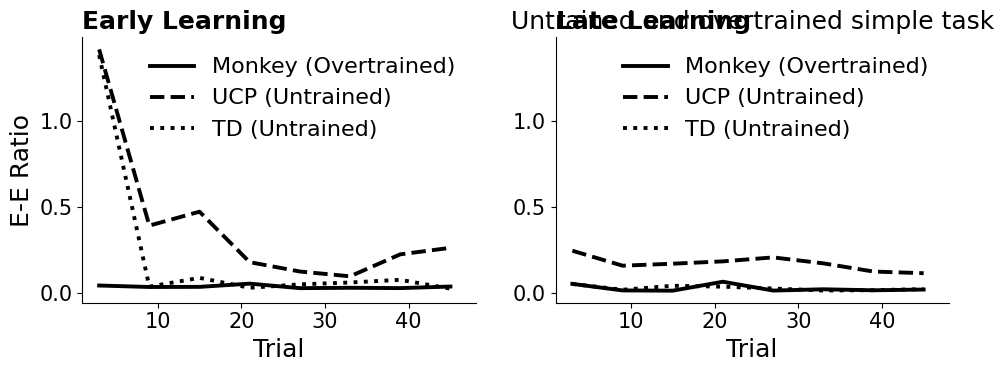

In [ ]:
# Early vs Late learning in ONE figure (two subplots, one legend)
from pathlib import Path

ratio_col = "exploration_exploitation_ratio"
bin_size = 6  # 48 trials -> 6 bins

# --- helpers (standalone safe)
def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _rank_sessions(s: pd.Series) -> pd.Series:
    uniq = pd.Series(pd.unique(s))
    uniq_num = pd.to_numeric(uniq, errors="coerce")
    if uniq_num.notna().any():
        order = uniq.iloc[np.argsort(uniq_num.fillna(np.inf).values)]
    else:
        order = uniq.astype(str).sort_values()
    mapping = {val: i + 1 for i, val in enumerate(order)}
    return s.map(mapping)

def _mean_by_trial(df, group_col="group", x_col="trial_index", y_col=ratio_col, unit_col="unit_id"):
    # Within-unit mean (protect against duplicates), then mean across units
    df_unit = df.groupby([group_col, x_col, unit_col], as_index=False)[y_col].mean()
    return (
        df_unit.groupby([group_col, x_col], as_index=False)[y_col]
        .mean()
        .rename(columns={y_col: "mean"})
        .sort_values([group_col, x_col])
    )

def _bin_progression(mean_df, x_col="trial_index", y_col="mean", bin_size=8):
    mean_df = mean_df.copy()
    mean_df["bin"] = ((mean_df[x_col].astype(int) - 1) // bin_size) + 1
    mean_df = mean_df[mean_df["bin"].between(1, int(np.ceil(48 / bin_size)))]
    out = (
        mean_df.groupby(["group", "bin"], as_index=False)[y_col]
        .mean()
        .rename(columns={y_col: "mean_bin"})
)
    out["x"] = (out["bin"] - 0.5) * bin_size
    return out.sort_values(["group", "bin"])

# Ensure required columns exist
if ratio_col not in monkeypr_df_filtered.columns:
    raise KeyError(f"{ratio_col} not found in monkeypr_df_filtered")
if ratio_col not in ucpmp_df.columns:
    raise KeyError(f"{ratio_col} not found in ucpmp_df")

# --- Monkey: define session rank within each exp_type; early = rank 1; late = last rank
monkey = monkeypr_df_filtered[["exp_type", "session_no", "trial_no", ratio_col]].copy()
monkey = monkey[monkey["session_no"] != 1].copy()
monkey[ratio_col] = pd.to_numeric(monkey[ratio_col], errors="coerce")
monkey["trial_index"] = pd.to_numeric(monkey["trial_no"], errors="coerce")
monkey = monkey.dropna(subset=[ratio_col, "trial_index"])
monkey["trial_index"] = monkey["trial_index"].astype(int)
monkey["session_rank"] = monkey.groupby("exp_type")["session_no"].transform(_rank_sessions)
monkey["unit_id"] = monkey["exp_type"].astype(str)
monkey = monkey[["unit_id", "session_rank", "trial_index", ratio_col]]

monkey_last_rank = monkey.groupby("unit_id")["session_rank"].max().reset_index(name="last_rank")
monkey = monkey.merge(monkey_last_rank, on="unit_id", how="left")

# --- Humans: normalize cohort + compute session rank within participant; within-session trial_index = 1..48
ucpmp_cohort_col = _find_col(ucpmp_df, ["Cohort", "cohort", "GROUP", "Group", "group"])
if ucpmp_cohort_col is None:
    raise KeyError("Could not find cohort column in ucpmp_df")

hum = ucpmp_df[["participant_id", "session_no", "trial_seq", ratio_col, ucpmp_cohort_col]].copy()
hum[ratio_col] = pd.to_numeric(hum[ratio_col], errors="coerce")
hum["trial_raw"] = pd.to_numeric(hum["trial_seq"], errors="coerce")
hum = hum.dropna(subset=[ratio_col, "trial_raw"])
hum["trial_raw"] = hum["trial_raw"].astype(int)
hum["cohort_norm"] = (
    hum[ucpmp_cohort_col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        "UCPMP": "UCP",
        "UCP ": "UCP",
        "UCP": "UCP",
        "TD": "TD",
        "TDC": "TD",
        "TYPICAL": "TD",
        "CONTROL": "TD",
    })
 )
hum = hum[hum["cohort_norm"].isin(["UCP", "TD"])]
hum["session_rank"] = hum.groupby("participant_id")["session_no"].transform(_rank_sessions)

# trial_index within session: sort by trial_raw then cumcount => 1..48
hum = hum.sort_values(["participant_id", "session_rank", "trial_raw"])
hum["trial_index"] = hum.groupby(["participant_id", "session_rank"]).cumcount() + 1
hum = hum[hum["trial_index"].between(1, 48)]
hum["unit_id"] = hum["participant_id"].astype(str)
hum = hum[["unit_id", "cohort_norm", "session_rank", "trial_index", ratio_col]]

legend_labels = {
    "Monkey": "Monkey (Overtrained)",
    "UCP": "UCP (Untrained)",
    "TD": "TD (Untrained)",
}
line_styles = {
    "Monkey": "-",
    "UCP": "--",
    "TD": ":",  # dotted ....
}

def _get_binned_for_condition(monkey_session_selector, human_session_rank, bin_size=8):
    monkey_sel = monkey.loc[monkey_session_selector(monkey)].copy()
    monkey_sel["group"] = "Monkey"
    monkey_sel = monkey_sel[["group", "unit_id", "trial_index", ratio_col]]

    hum_sel = hum.loc[hum["session_rank"] == human_session_rank].copy()
    hum_sel = hum_sel.rename(columns={"cohort_norm": "group"})
    hum_sel = hum_sel[["group", "unit_id", "trial_index", ratio_col]]

    all_df = pd.concat([monkey_sel, hum_sel], ignore_index=True)
    mean_df = _mean_by_trial(all_df)
    return _bin_progression(mean_df, bin_size=bin_size)

# Compute binned means
binned_early = _get_binned_for_condition(
    monkey_session_selector=lambda df: df["session_rank"] == 1,
    human_session_rank=1,
    bin_size=bin_size,
 )
binned_late = _get_binned_for_condition(
    monkey_session_selector=lambda df: df["session_rank"] == df["last_rank"],
    human_session_rank=2,
    bin_size=bin_size,
 )

# Bigger fonts for publication
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 16,
    "lines.linewidth": 2.8,
})

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
ax_early, ax_late = axes

def _plot_panel(ax, binned_df, panel_title):
    handles = []
    labels = []
    for g in ["Monkey", "UCP", "TD"]:
        sub = binned_df[binned_df["group"] == g]
        if sub.empty:
            continue
        (line,) = ax.plot(
            sub["x"],
            sub["mean_bin"],
            color="black",
            linestyle=line_styles.get(g, "-"),
            label=legend_labels.get(g, g),
        )
        handles.append(line)
        labels.append(legend_labels.get(g, g))

    ax.set_xlim(1, 48)
    ax.set_xlabel("Trial")
    ax.grid(False)
    sns.despine(ax=ax)
    ax.set_title(panel_title, fontweight="bold", loc="left")
    return handles, labels

handles1, labels1 = _plot_panel(ax_early, binned_early, "Early Learning")
handles2, labels2 = _plot_panel(ax_late, binned_late, "Late Learning")

# Y-axis labels: left only; keep numeric tick values on both panels
ax_early.set_ylabel("E-E Ratio")
ax_late.set_ylabel("")
ax_late.tick_params(axis="y", which="both", left=True, labelleft=True)


# Force the same y-limits on both panels based on combined data (early+late)
y_all = pd.concat([binned_early[["mean_bin"]], binned_late[["mean_bin"]]], ignore_index=True)
y_all = pd.to_numeric(y_all["mean_bin"], errors="coerce").dropna()
if not y_all.empty:
    y_min = float(y_all.min())
    y_max = float(y_all.max())
    pad = 0.05 * (y_max - y_min) if y_max > y_min else 0.05
    ax_early.set_ylim(y_min - pad, y_max + pad)
    ax_late.set_ylim(y_min - pad, y_max + pad)

# Legends on BOTH subplots (top-right)
if handles1:
    ax_early.legend(handles1, labels1, loc="upper right", frameon=False, fontsize=16)
if handles2:
    ax_late.legend(handles2, labels2, loc="upper right", frameon=False, fontsize=16)
elif handles1:
    ax_late.legend(handles1, labels1, loc="upper right", frameon=False, fontsize=16)

fig.tight_layout()
# plt.title("Untrained and overtrained simple task", loc="center")
# Save to save_path directory
if "save_path" in globals() and isinstance(save_path, str) and len(save_path.strip()) > 0:
    out_dir = Path(save_path)
else:
    out_dir = Path(".")
out_dir.mkdir(parents=True, exist_ok=True)

out_png = out_dir / f"EE_ratio_early_vs_late_bin{bin_size}.png"
fig.savefig(out_png, dpi=600, bbox_inches="tight")
print(f"Saved figure to: {out_png}")

plt.show()

In [20]:
# MonkeyPR: Early vs Late learning (split sessions into halves) — Mean ± 95% CI and paired p-value

import numpy as np
import pandas as pd
import scipy.stats as stats

ratio_col = "exploration_exploitation_ratio"

def mean_ci_t(x, alpha=0.05):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    n = int(x.shape[0])
    mean = float(x.mean()) if n else np.nan
    if n < 2:
        return mean, np.nan, np.nan, n
    sem = stats.sem(x, nan_policy="omit")
    h = stats.t.ppf(1 - alpha / 2, df=n - 1) * sem
    return mean, mean - h, mean + h, n

def paired_pvalue(wide_df, col_early="Early", col_late="Late"):
    tmp = wide_df[[col_early, col_late]].apply(pd.to_numeric, errors="coerce").dropna()
    if tmp.shape[0] < 2:
        return np.nan, np.nan, int(tmp.shape[0])
    t_stat, p_val = stats.ttest_rel(tmp[col_early], tmp[col_late])
    return float(t_stat), float(p_val), int(tmp.shape[0])

def _rank_sessions(s: pd.Series) -> pd.Series:
    """Map arbitrary session_no values to 1..K per exp_type in chronological order."""
    uniq = pd.Series(pd.unique(s))
    uniq_num = pd.to_numeric(uniq, errors="coerce")
    if uniq_num.notna().any():
        order = uniq.iloc[np.argsort(uniq_num.fillna(np.inf).values)]
    else:
        order = uniq.astype(str).sort_values()
    mapping = {val: i + 1 for i, val in enumerate(order)}
    return s.map(mapping)

# --- Load monkey data from previous cells
if "monkeypr_df_filtered" not in globals():
    raise NameError("Expected `monkeypr_df_filtered` to exist. Please run the earlier data loading/filtering cells first.")

if ratio_col not in monkeypr_df_filtered.columns:
    raise KeyError(f"{ratio_col} not found in monkeypr_df_filtered")

monkey = monkeypr_df_filtered[["exp_type", "session_no", ratio_col]].copy()
monkey = monkey[monkey["session_no"] != 1].copy()
monkey[ratio_col] = pd.to_numeric(monkey[ratio_col], errors="coerce")
monkey = monkey.dropna(subset=[ratio_col])

# Session rank within each exp_type
monkey["session_rank"] = monkey.groupby("exp_type")["session_no"].transform(_rank_sessions)

# Compute session-level mean per exp_type to make each session contribute equally
session_means = (
    monkey.groupby(["exp_type", "session_rank"], as_index=False)[ratio_col]
    .mean()
    .rename(columns={ratio_col: "session_mean"})
 )

# Number of sessions per exp_type and half-split cutoff
n_sessions = session_means.groupby("exp_type")["session_rank"].max().reset_index(name="n_sessions")
session_means = session_means.merge(n_sessions, on="exp_type", how="left")
session_means["cutoff"] = (session_means["n_sessions"] // 2).astype(int)

# Define phases: Early = first half sessions, Late = remaining sessions
session_means["phase"] = np.where(
    session_means["cutoff"] < 1,
    np.nan,
    np.where(session_means["session_rank"] <= session_means["cutoff"], "Early", "Late"),
 )

# Keep only exp_types with >= 2 sessions (cutoff >= 1)
session_means = session_means.dropna(subset=["phase"])

# Aggregate within phase per exp_type (average across sessions in that phase)
unit_phase_means = (
    session_means.groupby(["exp_type", "phase"], as_index=False)["session_mean"]
    .mean()
    .rename(columns={"session_mean": "phase_mean"})
 )

monkey_wide = (
    unit_phase_means.pivot(index="exp_type", columns="phase", values="phase_mean")
    .reindex(columns=["Early", "Late"])
)

# Summary stats across exp_types
early_mean, early_lo, early_hi, early_n = mean_ci_t(monkey_wide["Early"])
late_mean, late_lo, late_hi, late_n = mean_ci_t(monkey_wide["Late"])
t_stat, p_val, n_paired = paired_pvalue(monkey_wide)

summary = pd.DataFrame(
    [
        {"Group": "Monkey", "Phase": "Early", "Mean": early_mean, "CI_low": early_lo, "CI_high": early_hi, "n_units": early_n},
        {"Group": "Monkey", "Phase": "Late", "Mean": late_mean, "CI_low": late_lo, "CI_high": late_hi, "n_units": late_n},
    ]
 )

display(summary)

print("Paired Early vs Late p-value (unit = exp_type; Early=first half sessions; Late=second half):")
print(f"  Monkey: t = {t_stat:.3f}, p = {p_val:.4g}, n_paired = {n_paired}")
print("Included exp_types (n_sessions >= 2):", int(monkey_wide.dropna().shape[0]))

,Group,Phase,Mean,CI_low,CI_high,n_units
0,Monkey,Early,0.018643,0.009309,0.027977,4
1,Monkey,Late,0.065584,-0.090525,0.221693,4


Paired Early vs Late p-value (unit = exp_type; Early=first half sessions; Late=second half):
  Monkey: t = -0.917, p = 0.4269, n_paired = 4
Included exp_types (n_sessions >= 2): 4


In [16]:
monkeypr_df.columns

Index(['exp_type', 'session_no', 'trial_no', 'Time', 'HandPos', 'TargetPos',
       'time_diff_ms', 'path', 'target_poisiton', 'normalized_trajectory',
       'Cohort', 'completion_time', 'rmsd', 'is_success',
       'trajectory_embedding_default', 'exploration_score',
       'exploitation_score', 'exploration_exploitation_ratio', 'task_label'],
      dtype='object')